## EDA — Telco Customer Churn

#### Problema de Negócio (ML Canvas)
    * Objetivo: prever churn (cancelamento de clientes)
    * Tipo: classificação binária
    * Variável target: Churn

#### Valores:
	* Yes → churn
	* No → não churn

# Importando os dados

In [1]:
import pandas as pd

#importar dados
dados = pd.read_csv("../data/raw/Telco_Customer_Churn.csv")



### Visão Geral dos Dados

In [2]:

print("-"*100)
dados.info()


----------------------------------------------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15 

In [3]:

dados.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
dados.shape

(7043, 21)

In [5]:
#Conversão de tipos de dados.
dados["TotalCharges"] = pd.to_numeric(dados["TotalCharges"], errors="coerce")

In [6]:
# Tratamento de valores ausentes.
dados["TotalCharges"] = dados["TotalCharges"].fillna(
    dados["tenure"] * dados["MonthlyCharges"]
)

In [7]:
(dados["Churn"]
 .value_counts(normalize=True)
 .mul(100)
 .round(2)
 .astype(str) + "%")

Churn
No     73.46%
Yes    26.54%
Name: proportion, dtype: str

In [8]:
#Estatísticas básicas
dados.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

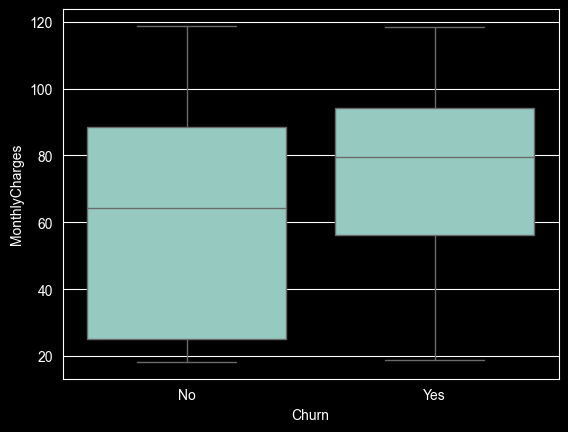

In [9]:
import seaborn as sns

sns.boxplot(x="Churn", y="MonthlyCharges", data=dados)


<Axes: xlabel='Churn', ylabel='tenure'>

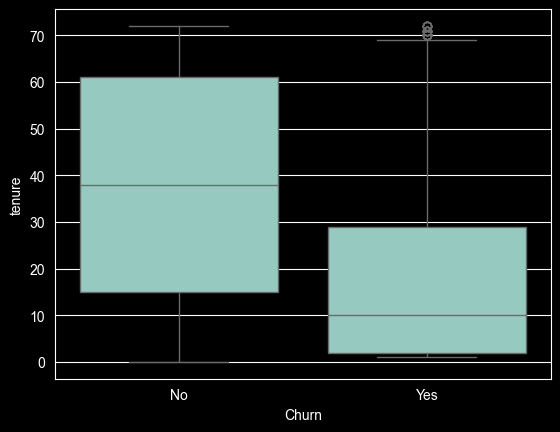

In [10]:
sns.boxplot(x="Churn", y="tenure", data=dados)

#### Insights típicos:
	•	clientes com churn:
	•	menor tenure
	•	maior MonthlyCharges

In [11]:
def calcularPercentualChurn(dados, coluna):
    resultado = (
        dados.groupby(coluna)["Churn"]
        .value_counts(normalize=True)
        .mul(100)
        .rename("percentual")
        .reset_index()
    )
    resultado = resultado.sort_values(by="percentual", ascending=False)
    resultado_formatado = resultado.round(2).astype(str) + "%"

    return resultado_formatado

In [12]:
for col in dados.columns:
    print("-" * 100)
    print(col.upper())
    print("-" * 100)
    print(calcularPercentualChurn(dados, col))

----------------------------------------------------------------------------------------------------
CUSTOMERID
----------------------------------------------------------------------------------------------------
       customerID Churn percentual
0     0002-ORFBO%   No%     100.0%
4691  6616-AALSR%   No%     100.0%
4702  6625-UTXEW%   No%     100.0%
4701  6625-IUTTT%   No%     100.0%
4700  6625-FLENO%   No%     100.0%
...           ...   ...        ...
2344  3352-RICWQ%   No%     100.0%
2343  3352-ALMCK%   No%     100.0%
2342  3351-NQLDI%  Yes%     100.0%
2341  3351-NGXYI%   No%     100.0%
7042  9995-HOTOH%   No%     100.0%

[7043 rows x 3 columns]
----------------------------------------------------------------------------------------------------
GENDER
----------------------------------------------------------------------------------------------------
    gender Churn percentual
2    Male%   No%     73.84%
0  Female%   No%     73.08%
1  Female%  Yes%     26.92%
3    Male%  Yes%     

In [13]:
dados.corr(numeric_only=True)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.103006
tenure,0.016567,1.000000,0.247900,0.826178
MonthlyCharges,0.220173,0.247900,1.000000,0.651174
TotalCharges,0.103006,0.826178,0.651174,1.000000


### Identificação de Problemas

##### Colunas que devem ser removidas
- customerID (ID)
- Linhas com valores mensais 0

##### Variáveis sensíveis
- gender (avaliar uso)

##### Drivers de churn:
- baixo tempo de contrato (tenure baixo)
- contratos mensais
- alto valor mensal
- método de pagamento eletrônico

## Limpar a base dados

In [14]:
#Remover colunas irrelevantes
if "customerID" in dados.columns:
    dados.drop("customerID", axis=1, inplace=True)


In [15]:
#Remover linhas com valores mensais 0
dados = dados[dados["MonthlyCharges"] > 0]
dados["MonthlyCharges"].min()

np.float64(18.25)

In [16]:
#Tratamento de churn.
dados["Churn"] = dados["Churn"].map({"Yes": 1, "No": 0})

In [17]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

dados_encoded = dados.copy()
colunas_para_remover = []
dfs_encoded = []

label_encoder = LabelEncoder()

for column in dados.columns:

    if dados[column].dtype == "str":

        print(dados[column].value_counts().head(10), "\n")

        quantidade_valores_unicos = dados[column].nunique()
        print(quantidade_valores_unicos, "\n")

        if quantidade_valores_unicos == 2:
            # binária → LabelEncoder
            dados_encoded[column] = label_encoder.fit_transform(dados[column])

        else:
            # categórica → OneHotEncoder
            encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

            encoded = encoder.fit_transform(dados[[column]])

            colunas = encoder.get_feature_names_out([column])

            df_temp = pd.DataFrame(
                encoded,
                columns=colunas,
                index=dados.index
            )

            dfs_encoded.append(df_temp)
            colunas_para_remover.append(column)

        print("-" * 100, "\n")

# juntar tudo
dados_encoded = pd.concat(
    [dados_encoded.drop(columns=colunas_para_remover)] + dfs_encoded,
    axis=1
)

dados_encoded.head()

gender
Male      3555
Female    3488
Name: count, dtype: int64 

2 

---------------------------------------------------------------------------------------------------- 

Partner
No     3641
Yes    3402
Name: count, dtype: int64 

2 

---------------------------------------------------------------------------------------------------- 

Dependents
No     4933
Yes    2110
Name: count, dtype: int64 

2 

---------------------------------------------------------------------------------------------------- 

PhoneService
Yes    6361
No      682
Name: count, dtype: int64 

2 

---------------------------------------------------------------------------------------------------- 

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64 

3 

---------------------------------------------------------------------------------------------------- 

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype:

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,1,0,0,0,2,1,1,53.85,108.15,1,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


#### Salvar a base de dados limpa


In [19]:
dados_encoded.to_csv("../data/processed/dados_limpos.csv", index=False)